# Fake Comet Photometry Demo

Builds a synthetic comet image (Gaussian PSF nucleus + `1/ρ` coma, plus sky noise), then measures its flux two ways:

- **PSF photometry** — a weighted point-source fit, same PSF as field stars.
- **5" aperture photometry** — a plain flux sum within a fixed circular aperture.

Self-contained: only `numpy` and `matplotlib` are required, so this runs as-is on Google Colab.

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import astropy.units as u

## Constants & unit conversions

In [81]:
PIXEL_SCALE = 0.2   # arcsec / pixel (LSST)
PIXEL_AREA_ARCSEC2 = PIXEL_SCALE ** 2  # arcsec^2 / pixel, for nJy/pixel -> nJy/arcsec^2
SKY_MAG = 21.2      # dark-sky surface brightness, r-band, mag/arcsec^2


def fwhm_to_sigma(fwhm):
    """Convert a Gaussian FWHM to sigma (same units in and out)."""
    return fwhm / (2 * np.sqrt(2 * np.log(2)))


def seeing_to_sigma_pixels(fwhm_arcsec, pixel_scale=PIXEL_SCALE):
    """Convert seeing (FWHM, arcsec) to a Gaussian sigma in pixels."""
    return fwhm_to_sigma(fwhm_arcsec / pixel_scale)


def ab_mag_to_njy(mag):
    """Convert an AB apparent magnitude to flux density in nanojansky."""
    return 3631e9 * 10 ** (-mag / 2.5)


def njy_to_ab_mag(flux_njy):
    """Convert a flux density in nanojansky to an AB apparent magnitude."""
    return -2.5 * np.log10(flux_njy / 3631e9)


def sky_flux_per_pixel(sky_mag, pixel_scale=PIXEL_SCALE):
    """Convert sky surface brightness (mag/arcsec^2) to flux per pixel, in nJy."""
    return ab_mag_to_njy(sky_mag) * pixel_scale ** 2


def rho_grid(shape, center):
    """Per-pixel distance from center, in pixels."""
    y, x = np.indices(shape)
    return np.sqrt((x - center[1]) ** 2 + (y - center[0]) ** 2)

## Comet model: Gaussian PSF nucleus + `1/ρ` coma

In [82]:
def make_nucleus_psf(shape, center, flux, sigma):
    """Generate a Gaussian PSF representing the bare nucleus, normalized to `flux`."""
    rho = rho_grid(shape, center)
    psf = np.exp(-rho ** 2 / (2 * sigma ** 2))
    return flux * psf / psf.sum()


def make_coma_profile(shape, center, flux, pixel_scale=PIXEL_SCALE):
    """
    Coma surface-brightness profile: surface brightness ~ 1/rho (in
    mJy/arcsec^2, via astropy units), converted to flux/pixel and
    normalized to `flux` (nJy, as a plain array).
    """
    y, x = np.mgrid[0:shape[0], 0:shape[1]]
    y = (y - center[0]) * pixel_scale * u.arcsec
    x = (x - center[1]) * pixel_scale * u.arcsec
    rho = np.hypot(y, x)

    # center pixel: 1/rho is convex, so the pixel's true average surface
    # brightness is E[1/rho] = 4*ln(1+sqrt(2))/pixel_scale (exact, from
    # integrating 1/rho over the pixel's area), not 1/(mean distance).
    # rho_eff is back-solved so that 1/rho_eff reproduces that average,
    # keeping the center pixel on the same rho -> 1/rho -> ... pipeline
    # as every other pixel instead of a separately maintained special case.
    center_row, center_col = int(round(center[0])), int(round(center[1]))
    rho_eff = 1 / (4 * np.log(1 + np.sqrt(2))) * pixel_scale * u.arcsec
    rho[center_row, center_col] = rho_eff

    # dropping units on rho to make sure coma has units mJy/arcsec**2
    coma_sb = 1 / rho.value * u.mJy / u.arcsec ** 2

    pixel_area = (pixel_scale * u.arcsec) ** 2
    coma_flux_per_pixel = (coma_sb * pixel_area).to(u.mJy).value

    return flux * coma_flux_per_pixel / coma_flux_per_pixel.sum()


def make_model_comet(
    shape=(101, 101),
    mag=20.0,
    nucleus_fraction=0.00,
    sigma=seeing_to_sigma_pixels(0.75),
    sky_mag=SKY_MAG,
    seed=None,
):
    """
    Build a full model comet image: nucleus PSF + coma, plus optional sky noise.

    mag is the apparent AB magnitude of the comet, converted to a total flux
    in nJy. nucleus_fraction sets what fraction of that flux goes into the
    unresolved nucleus PSF; the rest goes into the coma. sky_mag sets the
    per-pixel background noise level (pass None to skip noise entirely).
    """
    total_flux = ab_mag_to_njy(mag)
    nucleus_flux = nucleus_fraction * total_flux
    coma_flux = total_flux - nucleus_flux

    center = (shape[0] // 2, shape[1] // 2)
    nucleus = make_nucleus_psf(shape, center, nucleus_flux, sigma)
    coma = make_coma_profile(shape, center, coma_flux)
    image = nucleus + coma

    if sky_mag is not None:
        noise_sigma = np.sqrt(sky_flux_per_pixel(sky_mag))
        rng = np.random.default_rng(seed)
        image = image + rng.normal(0, noise_sigma, shape)

    return image

## Generate a fake comet

In [83]:
MAG = 18.0
SHAPE = (301, 301)  # half-width 150 px = 30", so the radial profile traces further out
SIGMA = seeing_to_sigma_pixels(0.75)  # 0.75" seeing -> pixels
center = (SHAPE[0] // 2, SHAPE[1] // 2)

print(f"Comet: mag={MAG}, total flux={ab_mag_to_njy(MAG):.1f} nJy")

Comet: mag=18.0, total flux=229100.6 nJy


### No noise

The pure model, before any sky background or noise is added.

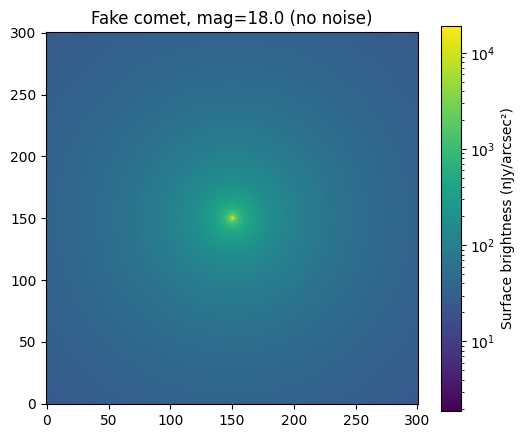

In [84]:
image_clean = make_model_comet(shape=SHAPE, mag=MAG, sigma=SIGMA, sky_mag=None)

plt.figure(figsize=(6, 5))
image_clean_sb = image_clean / PIXEL_AREA_ARCSEC2
norm = mcolors.LogNorm(vmin=image_clean_sb.max() * 1e-4, vmax=image_clean_sb.max())
plt.imshow(image_clean_sb, origin="lower", cmap="viridis", norm=norm)
plt.colorbar(label="Surface brightness (nJy/arcsec\u00b2)")
plt.title(f"Fake comet, mag={MAG} (no noise)")
plt.show()

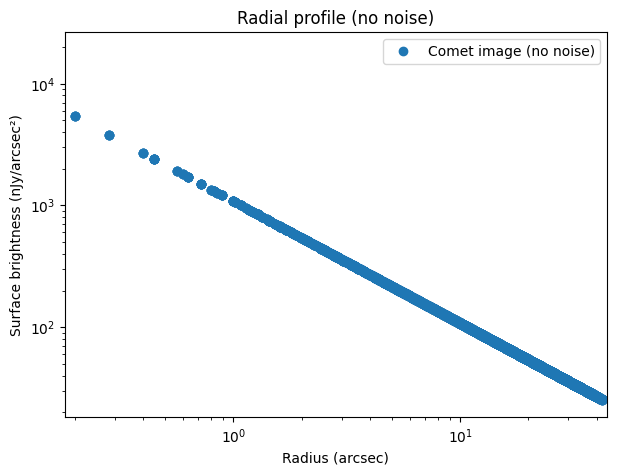

In [85]:
rho_arcsec_clean = rho_grid(SHAPE, center) * PIXEL_SCALE
order_clean = np.argsort(rho_arcsec_clean.ravel())
rho_sorted_clean = rho_arcsec_clean.ravel()[order_clean]
values_sorted_clean = image_clean.ravel()[order_clean] / PIXEL_AREA_ARCSEC2

plt.figure(figsize=(7, 5))
plt.plot(rho_sorted_clean, values_sorted_clean, color="tab:blue", ls = 'None', marker='o', label="Comet image (no noise)")
plt.xscale("log")
plt.yscale("log")
plt.xlim(left=0.9 * PIXEL_SCALE, right=rho_sorted_clean.max() * 1.05)
plt.xlabel("Radius (arcsec)")
plt.ylabel("Surface brightness (nJy/arcsec\u00b2)")
plt.title("Radial profile (no noise)")
plt.legend()
plt.show()

### Add sky noise

The version used for the rest of this notebook.

In [86]:
image = make_model_comet(shape=SHAPE, mag=MAG, sigma=SIGMA, seed=0)

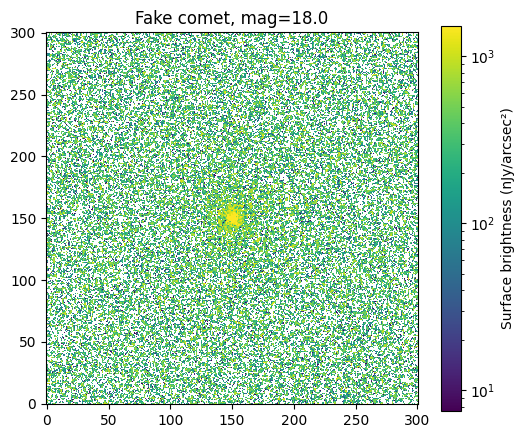

In [87]:
plt.figure(figsize=(6, 5))
image_sb = image / PIXEL_AREA_ARCSEC2  # nJy/pixel -> nJy/arcsec^2
vmax = np.percentile(image_sb, 99.5)
vmin = max(np.percentile(image_sb[image_sb > 0], 1), vmax * 1e-4)
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
plt.imshow(image_sb, origin="lower", cmap="viridis", norm=norm)
plt.colorbar(label="Surface brightness (nJy/arcsec\u00b2)")
plt.title(f"Fake comet, mag={MAG}")
plt.show()

## PSF photometry

In [88]:
def psf_photometry(image, center, sigma):
    """Estimate flux by fitting a point source with the given PSF sigma, via a weighted least-squares fit."""
    template = make_nucleus_psf(image.shape, center, flux=1.0, sigma=sigma)
    return np.sum(image * template) / np.sum(template ** 2)


psf_flux = psf_photometry(image, center, SIGMA)
psf_mag = njy_to_ab_mag(psf_flux)
print(f"PSF photometry:        flux={psf_flux:.2f} nJy  ->  mag={psf_mag:.3f}")

PSF photometry:        flux=5374.44 nJy  ->  mag=22.074


## 5" aperture photometry

In [89]:
def aperture_photometry(image, center, radius_arcsec, pixel_scale=PIXEL_SCALE):
    """Sum flux within a circular aperture of the given radius (arcsec)."""
    radius_px = radius_arcsec / pixel_scale
    rho = rho_grid(image.shape, center)
    return image[rho <= radius_px].sum()


APERTURE_RADIUS_ARCSEC = 5.0
aperture_flux = aperture_photometry(image, center, APERTURE_RADIUS_ARCSEC)
aperture_mag = njy_to_ab_mag(aperture_flux)
print(f'{APERTURE_RADIUS_ARCSEC}" aperture photometry:  flux={aperture_flux:.2f} nJy  ->  mag={aperture_mag:.3f}')

5.0" aperture photometry:  flux=34541.17 nJy  ->  mag=20.054


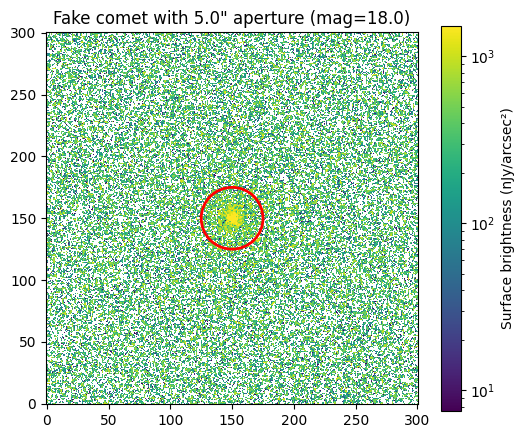

In [90]:
aperture_radius_px = APERTURE_RADIUS_ARCSEC / PIXEL_SCALE

fig, ax = plt.subplots(figsize=(6, 5))
image_sb = image / PIXEL_AREA_ARCSEC2  # nJy/pixel -> nJy/arcsec^2
vmax = np.percentile(image_sb, 99.5)
vmin = max(np.percentile(image_sb[image_sb > 0], 1), vmax * 1e-4)
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
im = ax.imshow(image_sb, origin="lower", cmap="viridis", norm=norm)
fig.colorbar(im, ax=ax, label="Surface brightness (nJy/arcsec\u00b2)")

circle = plt.Circle(center[::-1], aperture_radius_px, edgecolor="red", facecolor="none", linewidth=2)
ax.add_patch(circle)

ax.set_title(f'Fake comet with {APERTURE_RADIUS_ARCSEC}" aperture (mag={MAG})')
plt.show()

## Radial profile: data vs. PSF model

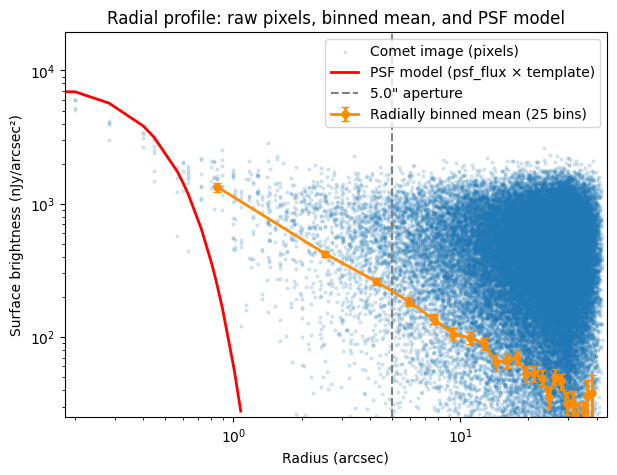

In [91]:
rho_arcsec = rho_grid(SHAPE, center) * PIXEL_SCALE

# actual pixel values vs radius, converted to surface brightness (nJy/arcsec^2)
order = np.argsort(rho_arcsec.ravel())
rho_sorted = rho_arcsec.ravel()[order]
values_sorted = image.ravel()[order] / PIXEL_AREA_ARCSEC2

# PSF model profile: the fitted point-source flux times the normalized PSF shape
psf_template = make_nucleus_psf(SHAPE, center, flux=1.0, sigma=SIGMA)
psf_model_sorted = (psf_flux * psf_template).ravel()[order] / PIXEL_AREA_ARCSEC2

# azimuthally binned mean -- averaging over many pixels at each radius cancels
# out the per-pixel noise, recovering the faint signal buried in the scatter
N_BINS = 25
bin_edges = np.linspace(0, rho_sorted.max(), N_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_indices = np.digitize(rho_sorted, bin_edges) - 1

bin_means = np.full(N_BINS, np.nan)
bin_errs = np.full(N_BINS, np.nan)
for i in range(N_BINS):
    in_bin = values_sorted[bin_indices == i]
    if len(in_bin) > 0:
        bin_means[i] = in_bin.mean()
        bin_errs[i] = in_bin.std() / np.sqrt(len(in_bin))  # standard error of the mean

plt.figure(figsize=(7, 5))
plt.scatter(rho_sorted, values_sorted, s=4, alpha=0.15, color="tab:blue", label="Comet image (pixels)")
plt.errorbar(bin_centers, bin_means, yerr=bin_errs, fmt="o-", color="darkorange", linewidth=2,
             markersize=5, capsize=3, label=f"Radially binned mean ({N_BINS} bins)")

# the model's Gaussian tail underflows toward zero -- drop the physically
# irrelevant deep tail rather than let it drag the log y-axis across hundreds of decades
FLOOR = 1.0 / PIXEL_AREA_ARCSEC2  # nJy/arcsec^2
psf_visible = psf_model_sorted > FLOOR
plt.plot(rho_sorted[psf_visible], psf_model_sorted[psf_visible], color="red", linewidth=2, label="PSF model (psf_flux × template)")
plt.axvline(APERTURE_RADIUS_ARCSEC, color="gray", linestyle="--", label=f'{APERTURE_RADIUS_ARCSEC}" aperture')

plt.xscale("log")
plt.yscale("log")
plt.xlim(left=0.9 * PIXEL_SCALE, right=rho_sorted_clean.max() * 1.05)
plt.ylim(bottom=FLOOR, top=values_sorted.max() * 1.01)
plt.xlabel("Radius (arcsec)")
plt.ylabel("Surface brightness (nJy/arcsec²)")
plt.title("Radial profile: raw pixels, binned mean, and PSF model")
plt.legend()
plt.show()

## PSF model residuals (2D)

Same comparison real pipelines use to validate a PSF model against an actual star (compare
to `psf_residuals_dp2.ipynb`) -- here applied to our fake comet, alongside a fake **star**
(all flux in the nucleus, no coma) at the same magnitude for contrast. The PSF model in both
cases is the Gaussian nucleus template (0.75" FWHM) scaled by the fitted `psf_flux`. A real
point source should leave a flat, noise-like residual with no structure -- the comet's
residual should instead clearly show the extended coma left over.

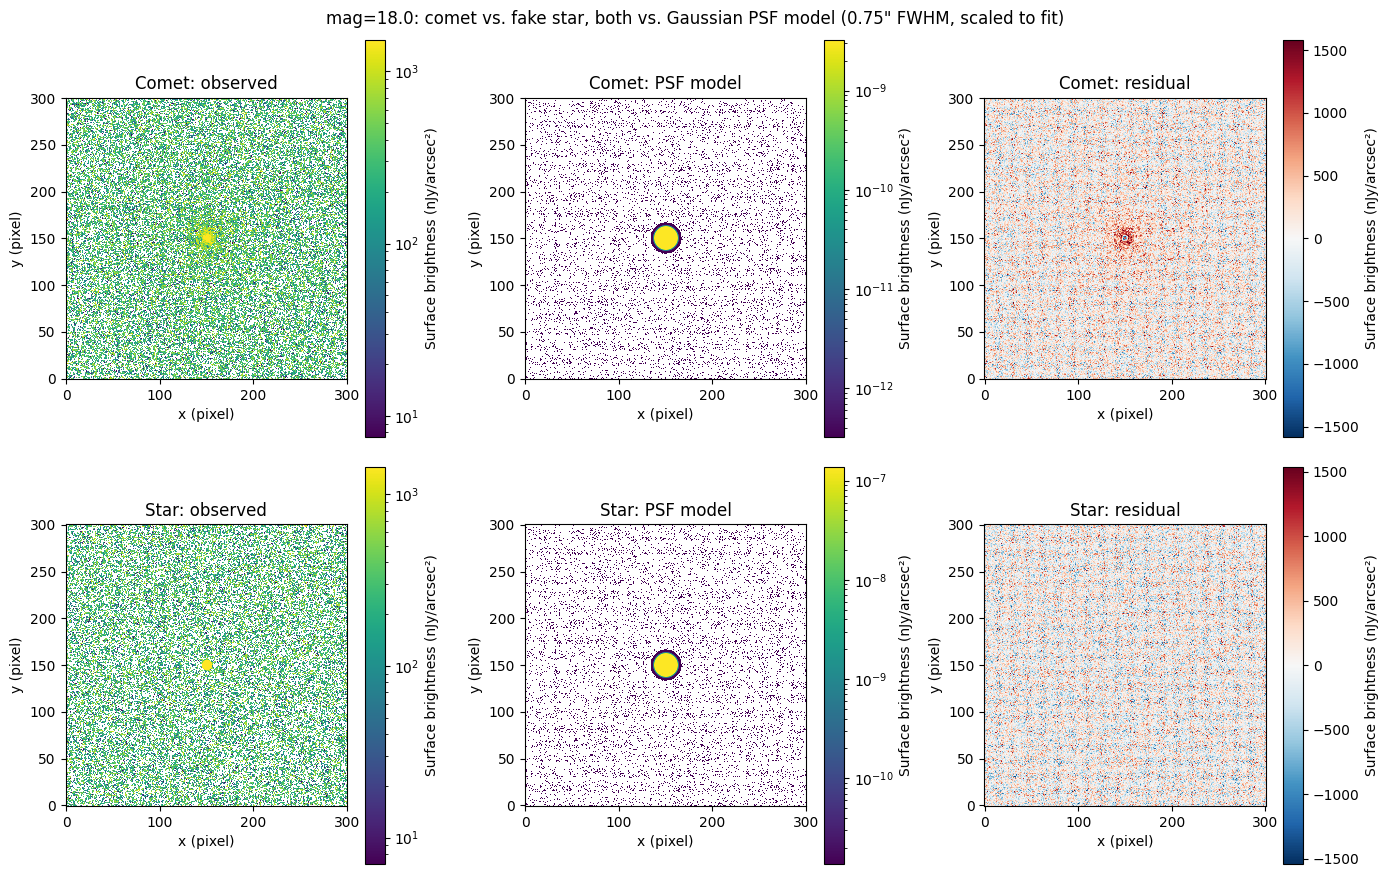

In [92]:
# A pure point source (all flux in the nucleus) at the same magnitude, for comparison --
# this is what a real PSF residual should look like: flat, noise-like, no structure.
star_image = make_model_comet(shape=SHAPE, mag=MAG, nucleus_fraction=1.0, sigma=SIGMA, seed=1)
star_psf_flux = psf_photometry(star_image, center, SIGMA)
star_psf_model = star_psf_flux * psf_template
star_residual = star_image - star_psf_model

psf_model_image = psf_flux * psf_template  # reuse psf_template from the radial profile above
residual_image = image - psf_model_image

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle(f'mag={MAG}: comet vs. fake star, both vs. Gaussian PSF model (0.75" FWHM, scaled to fit)', fontsize=12)

rows = [
    ("Comet", image, psf_model_image, residual_image),
    ("Star", star_image, star_psf_model, star_residual),
]

for row_axes, (label, observed, model, residual) in zip(axes, rows):
    # nJy/pixel -> nJy/arcsec^2 for display
    observed_sb = observed / PIXEL_AREA_ARCSEC2
    model_sb = model / PIXEL_AREA_ARCSEC2
    residual_sb = residual / PIXEL_AREA_ARCSEC2

    vmax_resid = np.percentile(np.abs(residual_sb), 99.5)

    def log_norm_for(img):
        img_vmax = np.percentile(img, 99.5)
        img_vmin = max(np.percentile(img[img > 0], 1), img_vmax * 1e-4)
        return mcolors.LogNorm(vmin=img_vmin, vmax=img_vmax)

    panels = [
        (observed_sb, f"{label}: observed", "viridis", log_norm_for(observed_sb)),
        (model_sb, f"{label}: PSF model", "viridis", log_norm_for(model_sb)),
        (residual_sb, f"{label}: residual", "RdBu_r", None),
    ]
    for ax, (img, title, cmap, norm) in zip(row_axes, panels):
        if norm is not None:
            im = ax.imshow(img, origin="lower", cmap=cmap, norm=norm)
        else:
            im = ax.imshow(img, origin="lower", cmap=cmap, vmin=-vmax_resid, vmax=vmax_resid)
        fig.colorbar(im, ax=ax, label="Surface brightness (nJy/arcsec\u00b2)")
        ax.set_title(title)
        ax.set_xlabel("x (pixel)")
        ax.set_ylabel("y (pixel)")

plt.tight_layout()
plt.show()

## Compare

In [93]:
true_mag = MAG
true_flux = ab_mag_to_njy(true_mag)

rows = [
    ("True", true_flux, true_mag),
    ("PSF", psf_flux, psf_mag),
    ('5" aperture', aperture_flux, aperture_mag),
]

print(f"{'Method':<15}{'Flux (nJy)':>15}{'Magnitude':>12}{'delta-mag':>12}")
for name, flux, mag in rows:
    print(f"{name:<15}{flux:>15.2f}{mag:>12.3f}{mag - true_mag:>12.3f}")

Method              Flux (nJy)   Magnitude   delta-mag
True                 229100.61      18.000       0.000
PSF                    5374.44      22.074       4.074
5" aperture           34541.17      20.054       2.054
